In [1]:
import zipfile
zip_path = "/content/mall customer segmentation.csv.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")


print("Dataset Extracted Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/mall customer segmentation.csv.zip'

In [3]:
import os
print(os.listdir("/content"))

['.config', 'sample_data']


In [5]:
import os
print(os.listdir("/content"))

['.config', 'mall customer segmentation.csv.zip', 'sample_data']


In [7]:
import zipfile

with zipfile.ZipFile('/content/mall customer segmentation.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Extracted!")

Extracted!


In [8]:
import os

print(os.listdir('/content/data'))

['Mall_Customers.csv']


In [18]:
import pandas as pd

df = pd.read_csv('/content/data/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [23]:
print(df.shape)

(200, 5)


In [25]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [26]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Dataset information
df.info()

Duplicate Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
import pandas as pd

df = pd.read_csv('/content/data/Mall_Customers.csv')

df.head()

## Data Validation

The dataset contains 200 customer records and 5 attributes.
Missing value analysis confirmed that no null values exist.
Duplicate record analysis confirmed that no duplicate entries exist.
The dataset is clean and suitable for analysis and reporting.

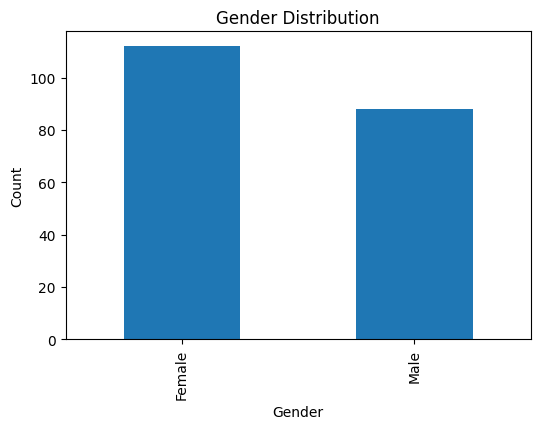

In [29]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,4))
gender_counts.plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

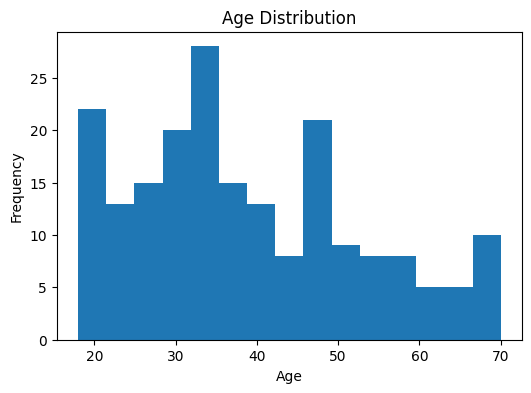

In [30]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=15)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

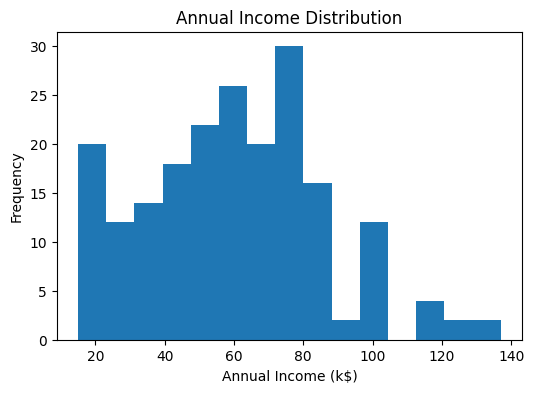

In [31]:
plt.figure(figsize=(6,4))
plt.hist(df['Annual Income (k$)'], bins=15)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

## Exploratory Data Analysis Findings

- Customer records are evenly distributed between genders.
- Most customers fall within the young to middle-age demographic.
- Annual income varies significantly across customers.
- Spending scores indicate multiple customer behavior patterns.

## Determining the Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of customer segments for K-Means clustering. The method evaluates the Within-Cluster Sum of Squares (WCSS) for different values of K.

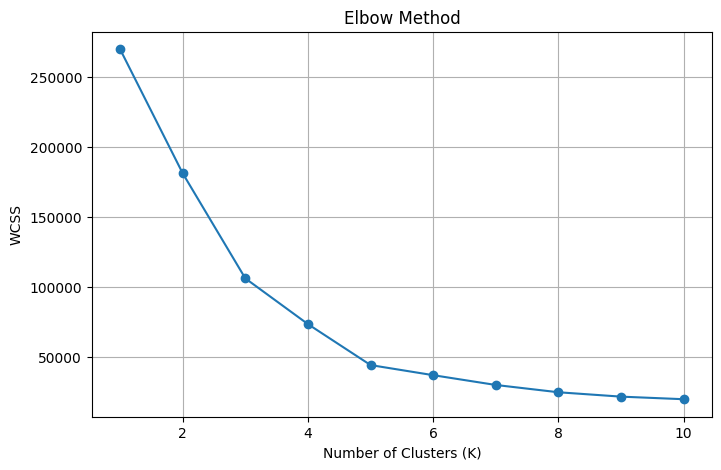

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [36]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

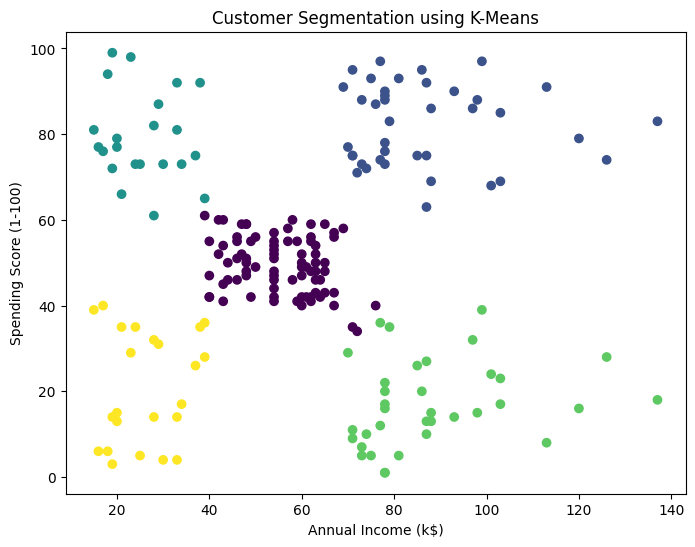

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means')
plt.show()

## Customer Segmentation Findings

The K-Means algorithm grouped customers into five distinct segments based on annual income and spending score.

### Segment Insights

1. High Income, High Spending
   - Premium customers
   - Most valuable customer segment

2. High Income, Low Spending
   - Customers with strong purchasing power but low engagement

3. Low Income, High Spending
   - Customers who spend heavily despite lower income

4. Low Income, Low Spending
   - Budget-conscious customers

5. Average Income, Average Spending
   - Regular customers with moderate purchasing behavior

## Conclusion

This project automated data validation, exploratory data analysis, and customer segmentation using Python.

The dataset was verified to contain no missing values or duplicate records. Multiple visualizations were generated to understand customer demographics and spending behavior.

K-Means clustering identified five customer segments, providing valuable insights for targeted marketing and customer relationship strategies.

The project demonstrates how data cleaning, reporting automation, and machine learning techniques can support business decision-making.

In [38]:
df.to_csv('cleaned_mall_customers.csv', index=False)

print("File saved successfully!")

File saved successfully!
